In [1]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#import the data
#data = pd.read_csv('Advertising.csv',index_col=0)
data= pd.read_csv('E:\Data Science\MLA\Linear Regression\Advertising.csv')

In [6]:
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


### Problem Statement and Domain Analysis
- The data is about the effect of advertising on the sales of the product.
- The data given contains the amount invested by differnt firms in different advertising media and the corresponding sales
- We are trying to evaluate the impact of advertising in different media on the sales.
- We will try to design a model that will predict the sales value based on amount invested in differnt media

In [7]:
data

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [9]:
data.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [10]:
#data.head(),data.tail(),data.TV.mean()
#sns.distplot(data.TV)
#sns.histplot(data.TV,kde=True)
#sns.pairplot(data)
data.isnull().sum()
#sns.boxplot(data.TV)

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

### Exploratory Data Analysis
- We will examine the spread of each feature and presence of outliers and the way to handle it as a part of univariate analysis
- We'll see how each feature affects the other features as well as sales individually as a part of bivariate analysis
- We'll see how features are inter-correlated, so as to filter highly correlated features.

<Figure size 500x500 with 0 Axes>

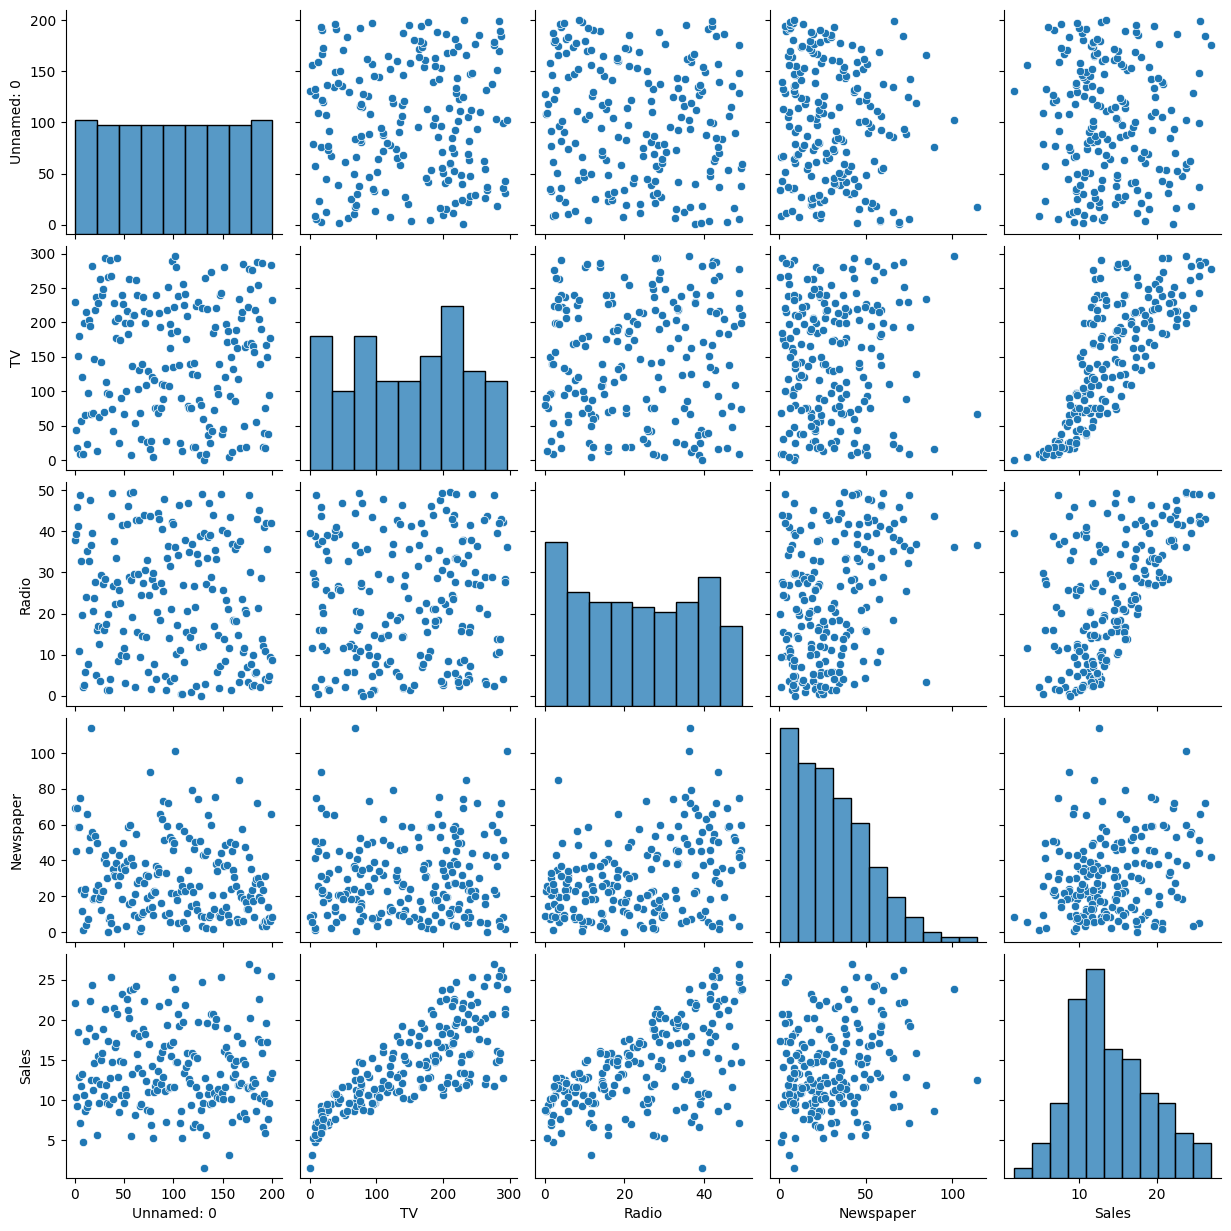

In [11]:
plt.figure(figsize=(5,5))
plt.tight_layout()
sns.pairplot(data)
plt.show()

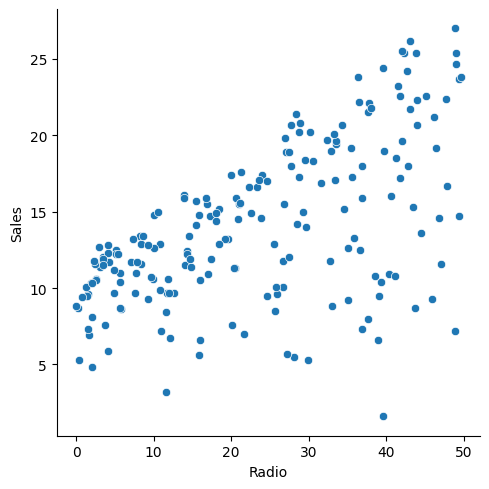

In [12]:
sns.relplot(x='Radio',y='Sales',data=data)

In [13]:
data.corr()

,Unnamed: 0,TV,Radio,Newspaper,Sales
Unnamed: 0,1.000000,0.017715,-0.110680,-0.154944,-0.051616
TV,0.017715,1.000000,0.054809,0.056648,0.782224
Radio,-0.110680,0.054809,1.000000,0.354104,0.576223
Newspaper,-0.154944,0.056648,0.354104,1.000000,0.228299
Sales,-0.051616,0.782224,0.576223,0.228299,1.000000


<Axes: >

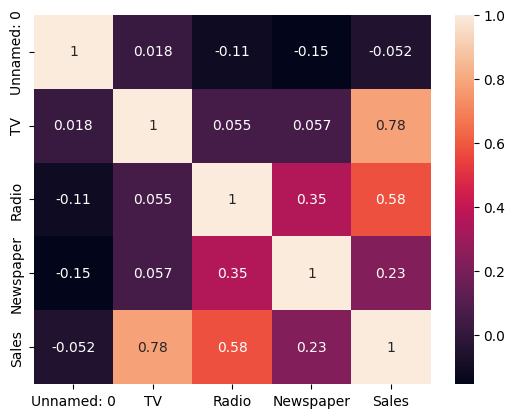

In [14]:
sns.heatmap(data.corr(),annot=True)

<Axes: ylabel='TV'>

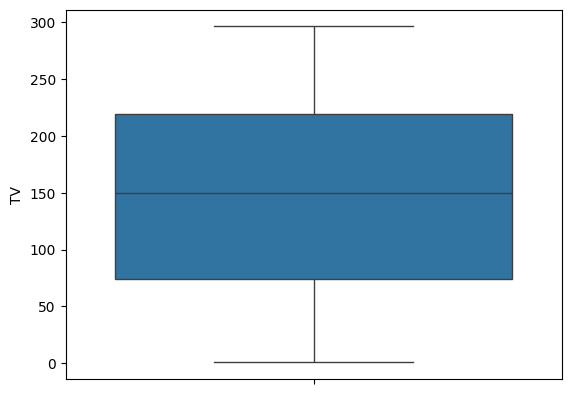

In [15]:
sns.boxplot(data.TV)

<Axes: xlabel='Newspaper'>

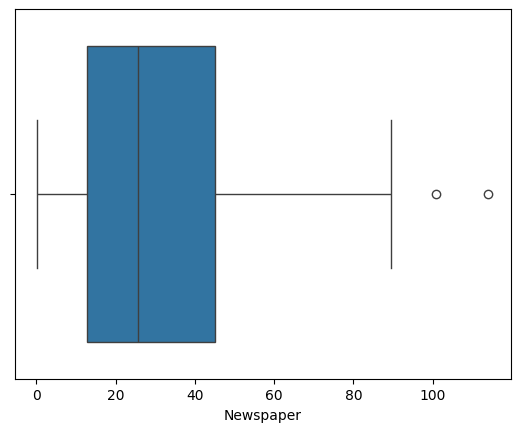

In [16]:
sns.boxplot(x='Newspaper',data=data)
#data.loc[(data.Newspaper>90),'Newspaper'] = data.Newspaper.mean()

<Axes: xlabel='TV'>

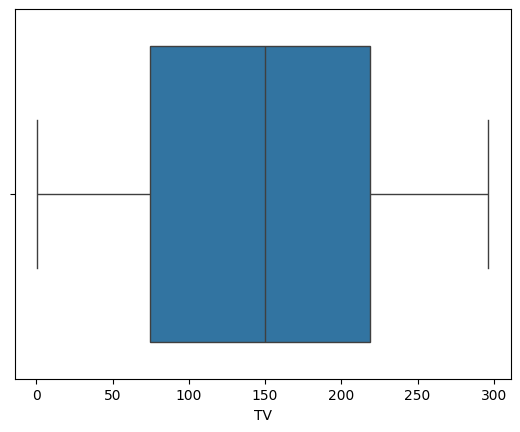

In [17]:
sns.boxplot(x='TV',data=data)

#### Observations from EDA - Insights:
- We see that all the features are linearly correlated with the target variable (sales) with sufficient varaibility witnessed in the graph.
- The features themselves do not show much correlation with each other, which makes them independent of each other. 

### Data Preprocessing and Feature Engineering
- Check for nullvalues and outliers and impute data- No null values
- Scaling/Encoding (Not required as data is pretty much in similar range)
- Selection of features (NO dropping of any features)

## Model Creations
- Separate features and target
- Train Test split
- Model creation and implementation

In [18]:
#Separating predictors/features and target
X = data.drop('Sales',axis=1)
Y = data.Sales

In [19]:
#Train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [20]:
print(len(X),len(x_train),len(x_test))

200 160 40


In [21]:
import sklearn
sklearn.set_config(print_changed_only=False)

In [22]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()
LR.fit(x_train,y_train)
LR

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
LR.coef_

array([0.00064359, 0.04471835, 0.18925118, 0.00304577])

In [24]:
LR.intercept_

np.float64(2.9065270863618125)

In [25]:
y_pred = LR.predict(x_test)

In [26]:
y_pred

array([16.41227699, 20.84319293, 21.51186915, 10.65309994, 22.12405753,
       13.12383506, 21.03748883,  7.50385439, 13.64787029, 15.12040886,
        9.02055551,  6.70666642, 14.40155146,  8.88609041,  9.74353333,
       12.21551975,  8.71370868, 16.2941451 , 10.26802337, 18.80498245,
       19.58864662, 13.22318303, 12.3647867 , 21.31473607,  7.79734749,
        5.78189965, 20.74934811, 11.95476656,  9.199109  ,  8.52178704,
       12.40431294,  9.94865202, 21.36880272, 12.25374832, 18.29943527,
       20.13347356, 14.07464638, 20.88594679, 11.05214979,  4.55168744])

In [27]:
df = pd.DataFrame()
df['Test'] = y_test
df['Predict'] = y_pred
df['Error'] = df.Test-df.Predict

In [28]:
df

,Test,Predict,Error
95,16.9,16.412277,0.487723
15,22.4,20.843193,1.556807
30,21.4,21.511869,-0.111869
158,7.3,10.653100,-3.353100
128,24.7,22.124058,2.575942
115,12.6,13.123835,-0.523835
69,22.3,21.037489,1.262511
170,8.4,7.503854,0.896146
174,11.5,13.647870,-2.147870
45,14.9,15.120409,-0.220409


In [29]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [30]:
print('Mean Squared Error: ',mean_squared_error(y_test,y_pred),'\nMean Absolute Error: ',mean_absolute_error(y_test,y_pred),
      '\nR2 Score: ',r2_score(y_test,y_pred),'\nRoot Mean Square Error (RMSE): ',mean_squared_error(y_test,y_pred)**0.5)

Mean Squared Error:  3.1990044685889067 
Mean Absolute Error:  1.465060105010293 
R2 Score:  0.898648915141708 
Root Mean Square Error (RMSE):  1.7885761008659673


In [31]:
r2 = r2_score(y_test,y_pred)
r2

0.898648915141708

- adjusted R2 score : 1- (1-R2)(n-1)/(n-p-1)
- n is data testing points, p is no. of independent variables, or predictors, or features

In [32]:
adj_r2 = 1-((1-r2)*(40-1)/(40-3-1))
adj_r2

0.890202991403517